## Creating ground truth dataframe for quantitative benchmarking comparison

In [2]:
import sys, subprocess

# 1. Uninstall torchaudio
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# 2. Install PyTorch with CUDA 12.4
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# 3. Install latest transformers and accelerate (allowing pip to pull compatible tokenizers naturally)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Installation complete — restart the kernel now")



✅ Installation complete — restart the kernel now


In [3]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [4]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")

Using device: cuda


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✅ Loaded successfully


In [5]:
print(torch.cuda.is_available())
print(torch.version.cuda)

True
12.4



Image: 001_dr_remy_ashford_c


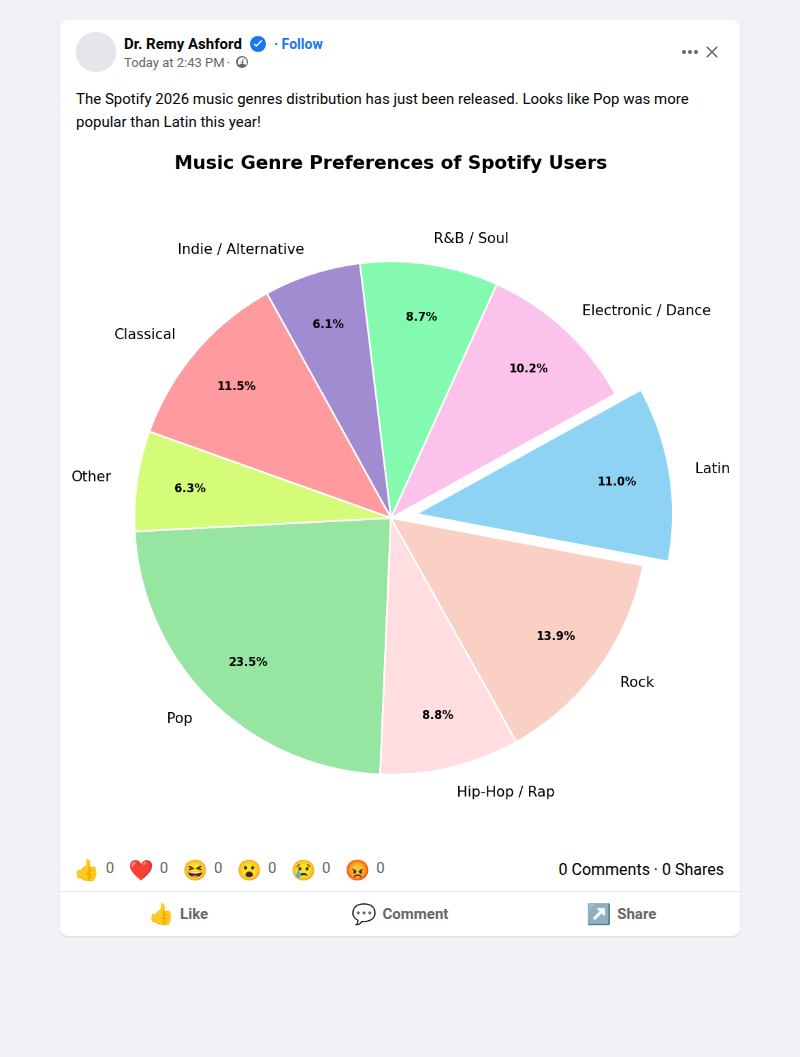

🔍 Querying VLM …


NameError: name 'process_vision_info' is not defined

In [6]:
import json
import re
import pandas as pd
from pathlib import Path
from IPython.display import display, Image as IPImage

BASE_DIR = Path(".")

QUESTIONS = [
    "profile_name", "profile_verification",
    "likes_count", "heart_reactions", "haha_reactions", "wow_reactions", "sad_reactions",
    "angry_reactions", "comment_count", "shares_count",
    "chart_percentages_pop", "chart_percentages_latin",
    "chart_color_pop", "chart_color_latin",
    "chart_largest_slice", "post_claim_correct"
]

variants = [
    ("correct", "_c"),
    ("incorrect", "_i"),
]

# Discover all PNG files from both variant folders automatically
image_paths = {}  # image_name -> (image_path, variant_folder)
for variant_folder, suffix in variants:
    folder = BASE_DIR / variant_folder
    for png in sorted(folder.glob("*.png")):
        image_name = png.stem  # filename without extension
        image_paths[image_name] = (png, variant_folder)

# ── Prompt sent to the VLM ────────────────────────────────────────────────────
SYSTEM_PROMPT = """\
You are a meticulous data-extraction assistant.
You will be shown a social-media post image and must answer a fixed set of questions
about its visible content. Reply ONLY with a valid JSON object whose keys are exactly
the field names listed below and whose values are strings.
Do NOT add extra keys, markdown fences, or any other text outside the JSON object.

Fields:
  profile_name          – exact text of the account/page name shown
  profile_verification  – "yes" if a verification badge is visible, else "no"
  likes_count           – total like count shown (digits only, e.g. if 1.2K, then "1200")
  heart_reactions       – heart/love reaction count (digits only)
  haha_reactions        – haha reaction count (digits only)
  wow_reactions         – wow reaction count (digits only)
  sad_reactions         – sad reaction count (digits only)
  angry_reactions       – angry reaction count (digits only)
  comment_count         – comment count shown (digits only)
  shares_count          – shares/retweets count shown (digits only)
  chart_percentages_pop – percentage value shown for "pop" in any chart (empty string if absent)
  chart_percentages_latin – percentage value shown for "latin" in any chart (empty string if absent)
  chart_color_pop       – colour of the "pop" slice/bar (empty string if absent)
  chart_color_latin     – colour of the "latin" slice/bar (empty string if absent)
  chart_largest_slice   – label of the largest chart segment (empty string if absent)
  post_claim_correct    – "correct" if the post is in the correct-variant folder, else "incorrect"
"""

USER_PROMPT = (
    "Extract the required fields from the image above and return a single JSON object."
)

def query_vlm(image_path: Path, variant_folder: str) -> dict:
    """Send one image to the already-loaded Qwen3-VL model and return a dict of answers."""
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(image_path)},
                {"type": "text",  "text": USER_PROMPT},
            ],
        },
    ]

    # Build inputs
    text_input = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    # Generate
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
        )

    # Decode only the newly generated tokens
    generated = output_ids[:, inputs["input_ids"].shape[1]:]
    raw_text = processor.batch_decode(
        generated, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    # Parse JSON – strip accidental markdown fences if present
    clean = re.sub(r"```(?:json)?|```", "", raw_text).strip()
    try:
        data = json.loads(clean)
    except json.JSONDecodeError:
        print(f"⚠️  Could not parse JSON for {image_path.name}. Raw output:\n{raw_text}\n")
        # Fall back: fill all fields with empty strings so the pipeline continues
        data = {q: "" for q in QUESTIONS}

    # Ensure every expected key is present
    for q in QUESTIONS:
        if q not in data:
            data[q] = ""

    # Override post_claim_correct from folder name (ground truth, not VLM guess)
    data["post_claim_correct"] = variant_folder

    return data


# ── Main loop ─────────────────────────────────────────────────────────────────
records = []

for image_name, (image_path, variant_folder) in image_paths.items():

    print(f"\n{'='*60}")
    print(f"Image: {image_name}")
    print(f"{'='*60}")
    display(IPImage(filename=str(image_path)))

    print("🔍 Querying VLM …")
    answers = query_vlm(image_path, variant_folder)

    row = {"image": image_name, "variant": variant_folder, **answers}
    records.append(row)

    # Save individual ground-truth file
    out_path = BASE_DIR / "ground_truth" / f"{image_name}_ground_truth.csv"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([row]).to_csv(out_path, index=False)
    print(f"✅ Saved: {out_path}")

    # Pretty-print the extracted values for a quick sanity check
    for k, v in answers.items():
        print(f"   {k}: {v}")

# Save combined ground truth
combined_path = BASE_DIR / "ground_truth" / "ground_truth_all.csv"
pd.DataFrame(records).to_csv(combined_path, index=False)
print(f"\n✅ Combined ground truth saved to: {combined_path}")
display(pd.DataFrame(records))

In [ ]:
import pandas as pd
df_all = pd.read_csv("ground_truth/ground_truth_all.csv")
df_all.info()